In [ ]:
import pandas as pd
import random as rd 
import numpy as np 
import yfinance as yf
import os 
import shutil
import re 
from datetime import datetime,timedelta,date
import time
import calendar
import sqlite3



class Classe_api_acoes() :
    def __init__(self) :
        self.desencadear()
    

    def desencadear(self) :
        self.gerar_requisicao()


    def gerar_requisicao(self) :
        caminho_ref = os.path.join(r".\bases_dados\acoes","base_acoes.json")
        caminho_db = os.path.join(r".\bases_dados\acoes","base_acoes.db")
        # Principais empresas: EUA + Brasil + Grandes mundiais
        tickers = [
            # Americanas
            "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA", "BRK-B", "JPM", "V",
            
            # Brasileiras
            "PETR4.SA", "VALE3.SA", "ITUB4.SA", "BBDC4.SA", "ABEV3.SA", "WEGE3.SA", "BBAS3.SA",
            
            # Grandes mundiais
            "NESN.SW", "ASML", "SAP", "MC.PA", "SHEL", "TTE",
            "TSM", "BABA", "0700.HK", "TM", "005930.KS"
        ]

        # Baixa os últimos 6 meses com TODAS as colunas
        df_fina0 = yf.download(tickers, period="6mo", auto_adjust=True, progress=False)
        df_fina1 = df_fina0.stack(level=1, future_stack=True).reset_index()
        df_fina1 = df_fina1[["Date", "Ticker", "Open", "High", "Low", "Close", "Volume"]]
        df_fina1 = df_fina1.fillna(0)
        display(df_fina1)
        df_fina1.to_json(caminho_ref,orient="records",force_ascii=False,indent=4)
        with sqlite3.connect(caminho_db) as conn :
            df_fina1.to_sql(
                name="acoes",
                con=conn,
                if_exists="replace",
                index=False
            )

    

Classe_api_acoes()


Price,Date,Ticker,Open,High,Low,Close,Volume
0,2026-02-17,005930.KS,0.000000,0.000000,0.000000,0.000000,0.0
1,2026-02-17,0700.HK,0.000000,0.000000,0.000000,0.000000,0.0
2,2026-02-17,AAPL,257.590311,265.815653,255.084787,263.409943,58469100.0
3,2026-02-17,ABEV3.SA,0.000000,0.000000,0.000000,0.000000,0.0
4,2026-02-17,AMZN,198.130005,201.740005,196.000000,201.149994,69879200.0
...,...,...,...,...,...,...,...
3635,2026-08-17,TSM,0.000000,0.000000,0.000000,0.000000,0.0
3636,2026-08-17,TTE,0.000000,0.000000,0.000000,0.000000,0.0
3637,2026-08-17,V,0.000000,0.000000,0.000000,0.000000,0.0
3638,2026-08-17,VALE3.SA,0.000000,0.000000,0.000000,0.000000,0.0


DataFrame original:
                            Close
Date                             
2026-01-01 00:00:00.000  0.397371
2026-01-01 00:00:00.010  0.991782
2026-01-01 00:00:00.020  2.530892
2026-01-01 00:00:00.030  3.802118
2026-01-01 00:00:00.040  2.559012

Shape: (1000, 1)

Picos encontrados: 30
Alturas (primeiras 5): [3.80211757 4.11947107 3.64910456 4.1834765  5.20837448]
Prominências (primeiras 5): [3.40474625 7.53150827 6.84462839 7.81600221 8.5232406 ]


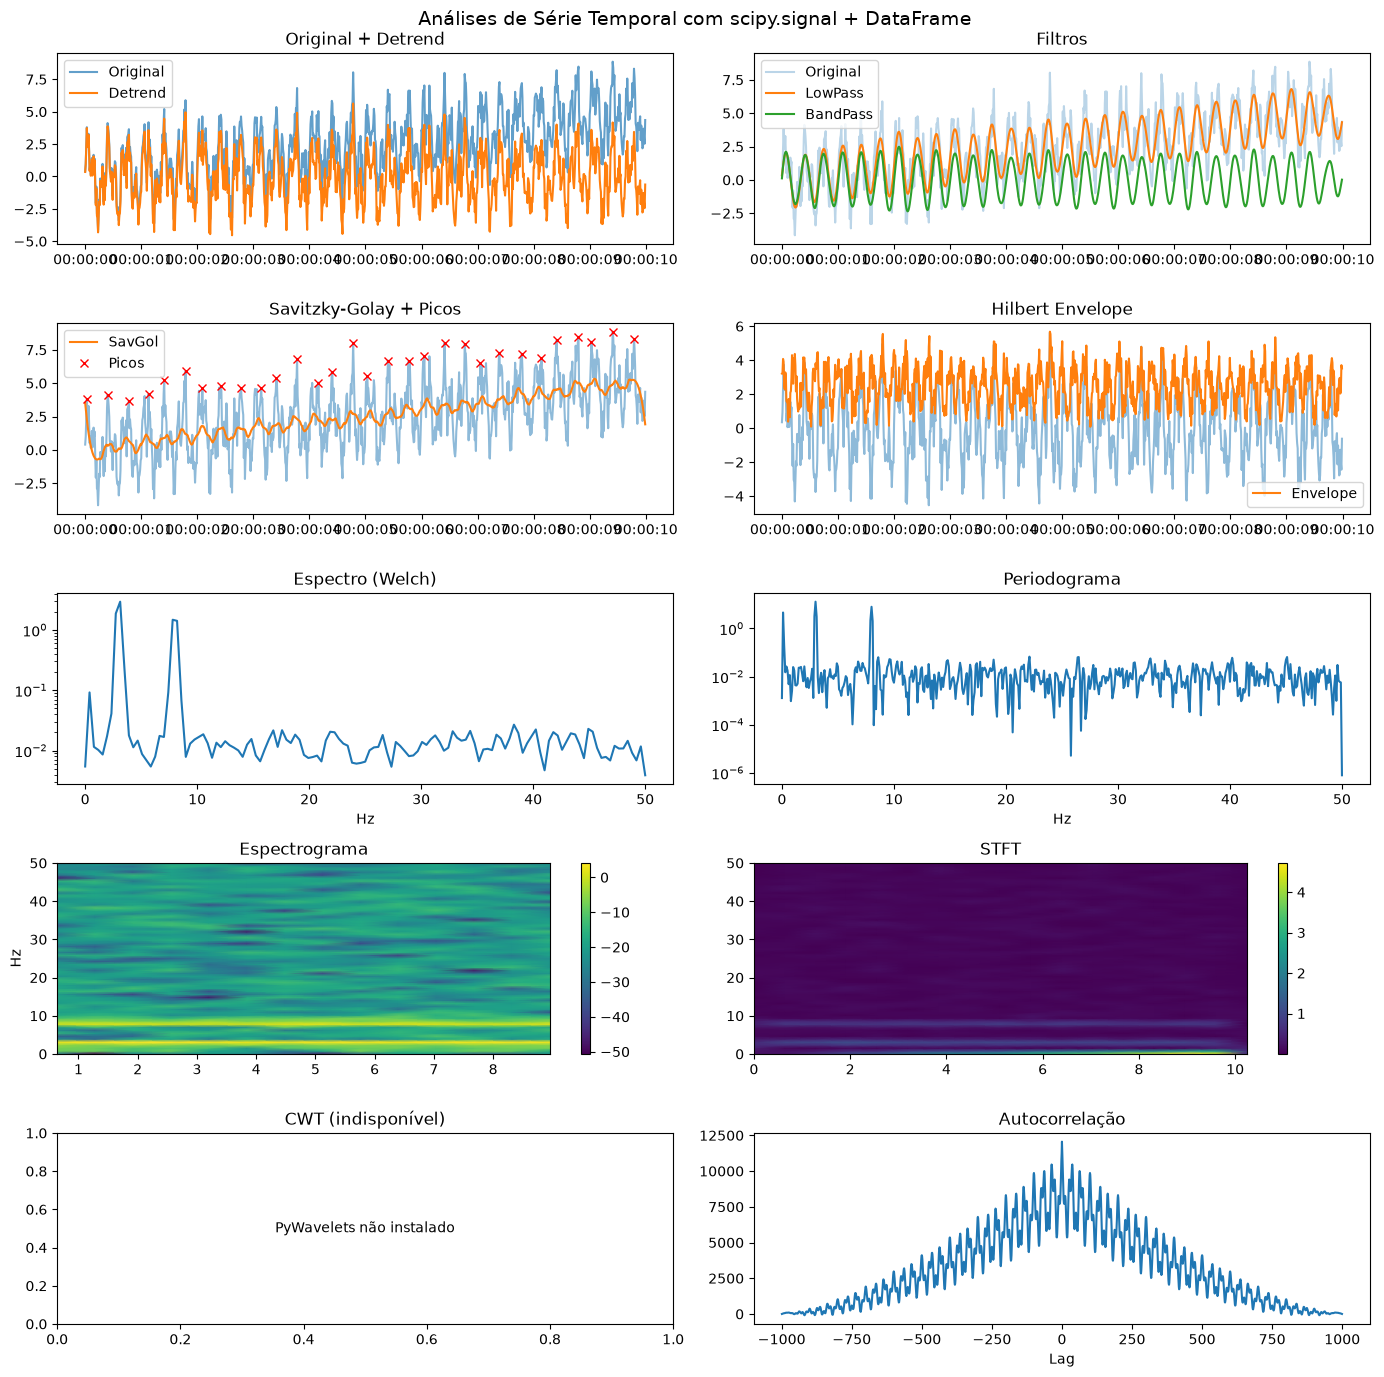


DataFrame final com todas as análises:
                            Close   Detrend   LowPass  HighPass  BandPass  \
Date                                                                        
2026-01-01 00:00:00.000  0.397371  0.349060  0.346762 -0.124533  0.115061   
2026-01-01 00:00:00.010  0.991782  0.938537  0.705393  0.217394  0.569598   
2026-01-01 00:00:00.020  2.530892  2.472712  1.053535  1.513903  0.997354   
2026-01-01 00:00:00.030  3.802118  3.739004  1.369991  2.563660  1.375941   
2026-01-01 00:00:00.040  2.559012  2.490964  1.636465  1.130785  1.686893   
2026-01-01 00:00:00.050  2.337402  2.264420  1.838943  0.760387  1.917018   
2026-01-01 00:00:00.060  3.291024  3.213108  1.968404  1.613715  2.059053   
2026-01-01 00:00:00.070  2.033927  1.951077  2.020824  0.310252  2.111563   
2026-01-01 00:00:00.080  0.504704  0.416919  1.996615 -1.208224  2.078214   
2026-01-01 00:00:00.090  0.989847  0.897128  1.899682 -0.654316  1.966595   

                           SavGol  

In [4]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import (
    butter, sosfiltfilt, find_peaks, peak_widths, peak_prominences,
    welch, periodogram, spectrogram, stft,
    hilbert, detrend, resample, savgol_filter, correlate
)


class Classe_analise_exploratoria_01:

    def __init__(self):
        self.desencadear()

    def desencadear(self):
        self.analises_01()

    def analises_01(self):
        # ============================================================
        # 1. Cria um DataFrame de exemplo (funciona sem arquivo externo)
        # ============================================================
        np.random.seed(42)
        fs = 100  # frequência de amostragem (Hz)
        t = np.arange(0, 10, 1/fs)

        values = (
            2 * np.sin(2 * np.pi * 3 * t) +
            1.5 * np.sin(2 * np.pi * 8 * t) +
            0.5 * t +
            0.8 * np.random.randn(len(t))
        )

        df = pd.DataFrame({
            "Date": pd.date_range("2026-01-01", periods=len(t), freq="10ms"),
            "Close": values
        }).set_index("Date")

        x = df["Close"].values

        print("DataFrame original:")
        print(df.head())
        print("\nShape:", df.shape)

        # ============================================================
        # 2. DETREND
        # ============================================================
        df["Detrend"] = detrend(x, type="linear")

        # ============================================================
        # 3. FILTRAGEM Butterworth
        # ============================================================
        sos_lp = butter(4, 5, btype="low", fs=fs, output="sos")
        df["LowPass"] = sosfiltfilt(sos_lp, x)

        sos_hp = butter(4, 4, btype="high", fs=fs, output="sos")
        df["HighPass"] = sosfiltfilt(sos_hp, x)

        sos_bp = butter(4, [2, 6], btype="band", fs=fs, output="sos")
        df["BandPass"] = sosfiltfilt(sos_bp, x)

        # ============================================================
        # 4. SAVITZKY-GOLAY
        # ============================================================
        df["SavGol"] = savgol_filter(x, window_length=51, polyorder=3)

        # ============================================================
        # 5. DETECÇÃO DE PICOS
        # ============================================================
        peaks, properties = find_peaks(x, height=1.5, distance=20, prominence=0.5)
        prominences = peak_prominences(x, peaks)[0]
        widths = peak_widths(x, peaks, rel_height=0.5)

        df["Peak"] = np.nan
        df.iloc[peaks, df.columns.get_loc("Peak")] = x[peaks]

        print("\nPicos encontrados:", len(peaks))
        if len(peaks) > 0:
            print("Alturas (primeiras 5):", properties["peak_heights"][:5])
            print("Prominências (primeiras 5):", prominences[:5])

        # ============================================================
        # 6. ANÁLISE ESPECTRAL
        # ============================================================
        f_welch, Pxx_welch = welch(x, fs=fs, window="hann", nperseg=256)
        f_per, Pxx_per = periodogram(x, fs=fs, window="hann")

        # ============================================================
        # 7. ESPECTROGRAMA e STFT
        # ============================================================
        f_spec, t_spec, Sxx = spectrogram(x, fs=fs, nperseg=128, noverlap=64)
        f_stft, t_stft, Zxx = stft(x, fs=fs, nperseg=128, noverlap=64)

        # ============================================================
        # 8. HILBERT (envelope)
        # ============================================================
        analytic = hilbert(df["Detrend"].values)
        df["Envelope"] = np.abs(analytic)
        df["InstPhase"] = np.unwrap(np.angle(analytic))

        # ============================================================
        # 9. WAVELET CONTÍNUA (usando PyWavelets)
        # ============================================================
        cwt_matrix = None
        if HAS_PYWT:
            scales = np.arange(1, 64)
            cwt_matrix, freqs = pywt.cwt(x, scales, wavelet="mexh", sampling_period=1/fs)

        # ============================================================
        # 10. AUTOCORRELAÇÃO
        # ============================================================
        autocorr = correlate(x, x, mode="full")
        lags = signal.correlation_lags(len(x), len(x), mode="full")

        # ============================================================
        # 11. RESAMPLING
        # ============================================================
        x_resampled = resample(x, num=len(x)//2)
        df_resampled = pd.DataFrame({
            "Close_resampled": x_resampled
        }, index=pd.date_range(df.index[0], periods=len(x_resampled), freq="20ms"))

        # ============================================================
        # 12. VISUALIZAÇÕES
        # ============================================================
        fig, axs = plt.subplots(5, 2, figsize=(14, 14))
        fig.suptitle("Análises de Série Temporal com scipy.signal + DataFrame", fontsize=14)

        # Original + Detrend
        axs[0, 0].plot(df.index, df["Close"], label="Original", alpha=0.7)
        axs[0, 0].plot(df.index, df["Detrend"], label="Detrend")
        axs[0, 0].legend()
        axs[0, 0].set_title("Original + Detrend")

        # Filtros
        axs[0, 1].plot(df.index, df["Close"], alpha=0.3, label="Original")
        axs[0, 1].plot(df.index, df["LowPass"], label="LowPass")
        axs[0, 1].plot(df.index, df["BandPass"], label="BandPass")
        axs[0, 1].legend()
        axs[0, 1].set_title("Filtros")

        # Savitzky-Golay + Picos
        axs[1, 0].plot(df.index, df["Close"], alpha=0.5)
        axs[1, 0].plot(df.index, df["SavGol"], label="SavGol")
        axs[1, 0].plot(df.index, df["Peak"], "rx", markersize=6, label="Picos")
        axs[1, 0].legend()
        axs[1, 0].set_title("Savitzky-Golay + Picos")

        # Envelope (Hilbert)
        axs[1, 1].plot(df.index, df["Detrend"], alpha=0.5)
        axs[1, 1].plot(df.index, df["Envelope"], label="Envelope")
        axs[1, 1].legend()
        axs[1, 1].set_title("Hilbert Envelope")

        # Welch
        axs[2, 0].semilogy(f_welch, Pxx_welch)
        axs[2, 0].set_title("Espectro (Welch)")
        axs[2, 0].set_xlabel("Hz")

        # Periodograma
        axs[2, 1].semilogy(f_per, Pxx_per)
        axs[2, 1].set_title("Periodograma")
        axs[2, 1].set_xlabel("Hz")

        # Espectrograma
        im = axs[3, 0].pcolormesh(t_spec, f_spec, 10 * np.log10(Sxx + 1e-10), shading="gouraud")
        axs[3, 0].set_title("Espectrograma")
        axs[3, 0].set_ylabel("Hz")
        fig.colorbar(im, ax=axs[3, 0])

        # STFT
        im2 = axs[3, 1].pcolormesh(t_stft, f_stft, np.abs(Zxx), shading="gouraud")
        axs[3, 1].set_title("STFT")
        fig.colorbar(im2, ax=axs[3, 1])

        # Wavelet (só se pywt estiver instalado)
        if HAS_PYWT and cwt_matrix is not None:
            im3 = axs[4, 0].imshow(np.abs(cwt_matrix), extent=[0, 10, 63, 1],
                                   aspect="auto", cmap="jet")
            axs[4, 0].set_title("CWT (Mexican Hat - PyWavelets)")
            axs[4, 0].set_ylabel("Escala")
            fig.colorbar(im3, ax=axs[4, 0])
        else:
            axs[4, 0].text(0.5, 0.5, "PyWavelets não instalado",
                           ha="center", va="center", transform=axs[4, 0].transAxes)
            axs[4, 0].set_title("CWT (indisponível)")

        # Autocorrelação
        axs[4, 1].plot(lags, autocorr)
        axs[4, 1].set_title("Autocorrelação")
        axs[4, 1].set_xlabel("Lag")

        plt.tight_layout()
        plt.show()

        # ============================================================
        # Resultado final
        # ============================================================
        print("\nDataFrame final com todas as análises:")
        print(df.head(10))
        print("\nColunas disponíveis:", df.columns.tolist())


# Executa a classe
Classe_analise_exploratoria_01()

In [ ]:
import pandas as pd 
import random as rd 
import numpy as np 
import os 
import shutil
import re 
from functools import partial
from toolz import compose,compose_left
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.cluster import KMeans
import plotly.express as px 
import pymc as pm



class Classe_analises_explo01() :
    def __init__(self) :
        self.desencadear()


    def desencadear(self) :
        self.carregar_tb_ori()
        # self.analise_exploratoria_01()
        # self.analise_exploratoria_02()
        self.criacao_base_treino_teste()
        self.criacao_modelo_bayes()



    def carregar_tb_ori(self) :
        caminho = r".\bases_dados\acoes\base_acoes.json"
        frame_tr = pd.DataFrame(pd.read_json(caminho))
        frame_tr["Date"] = pd.to_datetime(frame_tr["Date"],errors="coerce")
        frame_tr["Ano"] = frame_tr["Date"].map(lambda x : x.year)
        frame_tr["Mes"] = frame_tr["Date"].map(lambda x : x.month)
        frame_tr = frame_tr.sort_values(by="Date").reset_index(drop=True)
        self.frame_tot = frame_tr.copy()
        filtro_01 = frame_tr[frame_tr["Ticker"] == "WEGE3.SA"].reset_index(drop=True)
        filtro_02 = filtro_01[filtro_01["Open"] > 0].reset_index(drop=True)
        self.frame_tr = filtro_02.copy()


    def analise_exploratoria_01(self) :
        decolder = LabelEncoder()
        df_corr = self.frame_tr.copy()
        for col in df_corr.columns :
            if df_corr[col].dtypes == "object" :
                df_corr[col] = decolder.fit_transform(df_corr[col])
        df_corr_1 = df_corr.corr(method="pearson").reset_index().rename(columns={"index":"Valores"})
        target = "Close"
        colunas_ref0 = [x for x in list(df_corr_1.columns) if x not in [target,"Valores","Ticker"]]
        lista_vazia = []
        for col in colunas_ref0 :
            filtro_ref = df_corr_1[df_corr_1["Valores"] == target].reset_index(drop=True)
            val_ref = filtro_ref.loc[0,col]
            lista_vazia.append({
                "Alvo":target,
                "Vairavel":col,
                "Valor":val_ref
            })
        frame_final = pd.DataFrame(lista_vazia)
        display(frame_final)


    def funcao_aux1(self,x) :
        if x == 0 :
            return "A"
        elif x == 1 :
            return "B"
        elif x == 2 :
            return "C"


        
    def analise_exploratoria_02(self) :
        colunas_ref = ["Close","Open","High","Low","Volume"]
        df_cluster = self.frame_tot.copy()
        X = self.frame_tot[colunas_ref].copy()
        scaler_x = StandardScaler()
        x_scaled = scaler_x.fit_transform(X)
        n_clusters = 3
        grafico_01 = px.line(self.frame_tr,x="Date",y=["Close","High"],markers=True,title="Tendencia WEG",template="plotly_dark")
        grafico_01.show()
        kmeans = KMeans(
            n_clusters=n_clusters,
            random_state=42,
            n_init=10
        )
        df_cluster["Clusters"] = kmeans.fit_predict(x_scaled)
        df_cluster["Clusters"] = df_cluster["Clusters"].map(self.funcao_aux1)
        grafico_02 = px.scatter(df_cluster,x="Date",y="Close",color="Ticker",symbol="Clusters",title="Agrupamentos",template="plotly_dark")
        grafico_02.show()
        display(df_cluster)
        grafico_03 = px.scatter_3d(df_cluster,x="Close",y="Open",z="Volume",symbol="Ticker",color="Clusters",template="plotly_dark")
        grafico_03.show()



    def criacao_base_treino_teste(self) :
        df_train = self.frame_tr.iloc[(len(self.frame_tr) - 30):(len(self.frame_tr) - 4)].reset_index(drop=True)
        df_test = self.frame_tr.iloc[(len(self.frame_tr) - 4):].reset_index(drop=True)
        self.df_test0 = df_test.copy()
        self.stander_x = StandardScaler()
        self.stander_y = StandardScaler()
        target = "Close"
        features = [x for x in list(self.frame_tr.columns) if x not in [target,"Date","Ticker"]]
        self.x_train = self.stander_x.fit_transform(df_train[features])
        self.x_test = self.stander_x.transform(df_test[features])
        self.y_train = self.stander_y.fit_transform(df_train[[target]]).flatten()
        self.y_test = self.stander_y.transform(df_test[[target]]).flatten()
        print(f"Shape x_train {self.x_train.shape}")
        print(f"Shape x_test {self.x_test.shape}")
        print(f"Shape y_train {self.y_train.shape}")
        print(f"Shape y_test {self.y_test.shape}")



    def criacao_modelo_bayes(self) :
        with pm.Model() as model :
            X_data = pm.Data("X_data",self.x_train)
            y_data = pm.Data("y_data",self.y_train)
            alpha = pm.Normal("alpha", mu=0, sigma=1)
            beta = pm.Normal("beta", mu=0, sigma=1, shape=self.x_train.shape[1])
            sigma = pm.HalfNormal("sigma", sigma=1)
            mu = alpha + pm.math.dot(X_data,beta)
            Y_obs = pm.Normal("Y_obs",mu=mu,sigma=sigma,observed=y_data)
            idata = pm.sample(draws=150,tune=150,chains=1,cores=1)
        with model :
            pm.set_data({"X_data":self.x_test,"y_data":self.y_test})
            predictios = pm.sample_posterior_predictive(idata,var_names=["Y_obs"],predictions=True).predictions
            y_predct0 = predictios["Y_obs"].mean(dim=("chain", "draw")).values
            y_predct1 = self.stander_y.inverse_transform(y_predct0.reshape(-1,1)).flatten()
            y_real = self.stander_y.inverse_transform(self.y_test.reshape(-1,1)).flatten()
            lista_frame = []
            for val_ref0,val_ref1 in zip(y_predct1,y_real) :
                lista_frame.append({
                    "Real": val_ref1,
                    "Previsto": val_ref0
                })
            frame_final = pd.DataFrame(lista_frame)
            frame_final1 = pd.concat([frame_final,self.df_test0],axis=1)
            display(frame_final1)


    


Classe_analises_explo01()

Initializing NUTS using jitter+adapt_diag...


Shape x_train (26, 6)
Shape x_test (4, 6)
Shape y_train (26,)
Shape y_test (4,)


Sequential sampling (1 chains in 1 job)
NUTS: [alpha, beta, sigma]


c:\Users\beliasf\Desktop\Projetos\Agente_Acoes_V0\testes\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 1 chain for 150 tune and 150 draw iterations (150 + 150 draws total) took 14 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks
Sampling: [Y_obs]


c:\Users\beliasf\Desktop\Projetos\Agente_Acoes_V0\testes\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

,Real,Previsto,Date,Ticker,Open,High,Low,Close,Volume,Ano,Mes
0,47.360001,47.367491,2026-08-11,WEGE3.SA,47.570000,47.939999,46.930000,47.360001,5572800,2026,8
1,47.639999,47.921120,2026-08-12,WEGE3.SA,47.360001,48.080002,47.360001,47.639999,8033500,2026,8
2,47.500000,47.680644,2026-08-13,WEGE3.SA,47.400002,48.139999,47.240002,47.500000,4982500,2026,8
3,47.500000,46.943464,2026-08-14,WEGE3.SA,47.500000,47.610001,46.660000,47.500000,7327700,2026,8


In [ ]:
import pandas as pd 
import random as rd 
import numpy as np 
import os 
import shutil
import re 
from sklearn.preprocessing import LabelEncoder,StandardScaler
import sqlite3


class CLasse_teste_model() :
    def __init__(self) :
        self.desencadear()


    def desencadear(self) :
        self.carregar_tb_ori()


    def carregar_tb_ori(self) :
        caminho = r".\bases_dados\acoes\base_acoes.db"
        conexao = sqlite3.connect(caminho)
        frame_tr = pd.DataFrame(pd.read_sql_query(f"""SELECT * FROM acoes""",conexao))
        frame_tr = frame_tr[frame_tr["Open"] > 0].reset_index(drop=True)
        display(frame_tr)


CLasse_teste_model()

,Date,Ticker,Open,High,Low,Close,Volume
0,2026-02-17 00:00:00,AAPL,257.590311,265.815653,255.084787,263.409943,58469100.0
1,2026-02-17 00:00:00,AMZN,198.130005,201.740005,196.000000,201.149994,69879200.0
2,2026-02-17 00:00:00,ASML,1387.740124,1423.545562,1377.954236,1414.855835,1097200.0
3,2026-02-17 00:00:00,BABA,154.951926,156.690959,152.063460,154.015518,6803600.0
4,2026-02-17 00:00:00,BRK-B,500.019989,506.089996,499.209991,503.410004,4263300.0
...,...,...,...,...,...,...,...
3471,2026-08-14 00:00:00,VALE3.SA,71.550003,71.980003,71.089996,71.300003,22933800.0
3472,2026-08-14 00:00:00,WEGE3.SA,47.500000,47.610001,46.660000,47.500000,7327700.0
3473,2026-08-17 00:00:00,0700.HK,444.799988,450.399994,442.600006,446.399994,19843908.0
3474,2026-08-17 00:00:00,MC.PA,456.000000,459.700012,449.250000,449.950012,174256.0


In [11]:
import pandas as pd 
import os 
import sqlite3
import pprint


conn = sqlite3.connect(r".\bases_dados\acoes\base_acoes.db")
query = f"""SELECT * FROM acoes """
frame_tr = pd.DataFrame(pd.read_sql_query(query,conn))
filtro = frame_tr.drop_duplicates(subset=["Nome_Empresa","Ticker"]).reset_index(drop=True)
caminho_txt = r".\documentos\empresas\empresas.json"
frame_js = filtro[["Nome_Empresa","Ticker"]].to_json(caminho_txt,orient="records",force_ascii=False,indent=4)

